# Assignment 4 — How Few Components Can You Get Away With?
**Feature Engineering & MLOps · Dimensionality Reduction (PCA Practical)**

**Goal:** find the smallest number of principal components for which a Linear Regression model matches the test R² of the model trained on all 60 raw features, and explain why using the scree plot and explained variance.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 4.1 — Baseline: all 60 raw features

In [5]:
# Adjust the path if your copy lives elsewhere (e.g. data/raw/pca_regression_data.csv)
import os
import pandas as pd

path = "data/raw/pca_regression_data.csv"
if not os.path.exists(path):
    path = "/mnt/user-data/uploads/pca_regression_data.csv"

if not os.path.exists(path):
    # Fallback to current working directory if uploaded to Colab home
    if os.path.exists("pca_regression_data.csv"):
        path = "pca_regression_data.csv"
    else:
        raise FileNotFoundError(
            f"Could not find 'pca_regression_data.csv' in standard paths. "
            "Please upload the file to your Colab session and update the 'path' variable."
        )

df = pd.read_csv(path)
print("Shape:", df.shape, "| missing values:", int(df.isna().sum().sum()))

# student_id is an identifier, NOT a feature -> excluded. Only feature_1..feature_60 are used.
feature_cols = [f"feature_{i}" for i in range(1, 61)]
X = df[feature_cols]
y = df["score"]
print("Number of features used:", X.shape[1])
df.head()

Shape: (800, 62) | missing values: 0
Number of features used: 60


,student_id,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,score
0,1,1.006103,2.625090,-0.021036,6.231392,3.147998,-0.044665,-3.420442,1.567874,0.189118,...,3.515794,-1.345712,1.038361,1.358821,4.510162,-0.345406,3.255827,0.607355,1.126482,-0.319225
1,2,4.442871,-2.006560,-1.181818,1.695413,-3.168459,-5.989658,-2.662836,-4.174475,-2.323000,...,1.640106,4.207556,-3.367389,1.398171,1.162581,0.681762,-4.742943,2.150911,-5.587529,3.418536
2,3,1.723720,-3.352754,1.020613,0.533918,3.769766,-0.004683,-0.019345,0.515542,-0.225922,...,0.874327,-0.868329,1.769608,-1.165895,1.189553,3.324718,-1.858829,2.980939,1.121997,2.618471
3,4,0.411140,2.025221,-2.621914,-5.890728,-1.068567,3.413866,3.243600,4.476142,2.650463,...,-0.967199,-1.848642,1.535045,-4.300282,-5.457053,1.066226,2.996332,4.766362,1.312600,-3.740992
4,5,1.011855,3.029584,-2.574027,-1.983156,-1.696483,-2.258118,-1.735768,0.689373,-0.849770,...,-1.185252,-0.883210,0.022223,-1.336599,2.028197,-2.490620,1.414216,-1.392051,0.611356,1.294747


In [6]:
# 1. Train/test split (75/25, fixed random_state)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

# 2. Standardize: fit on TRAIN only, then apply to test (no leakage)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# 3. Baseline Linear Regression on all 60 standardized features
baseline_model = LinearRegression().fit(X_train_s, y_train)
baseline_r2 = r2_score(y_test, baseline_model.predict(X_test_s))
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Baseline test R² (60 raw features): {baseline_r2:.4f}")

Train size: 600, Test size: 200
Baseline test R² (60 raw features): 0.8584


## 4.2 — PCA: explained variance and the scree plot

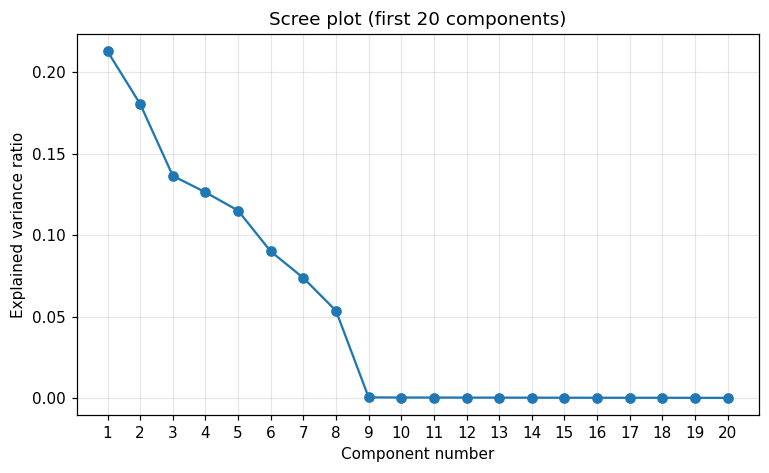

In [7]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_s)   # no n_components limit, train only
evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

n_show = 20
comp = np.arange(1, n_show + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(comp, evr[:n_show], "o-", color="tab:blue")
ax.set_xticks(comp)
ax.set_xlabel("Component number")
ax.set_ylabel("Explained variance ratio")
ax.set_title("Scree plot (first 20 components)")
plt.show()

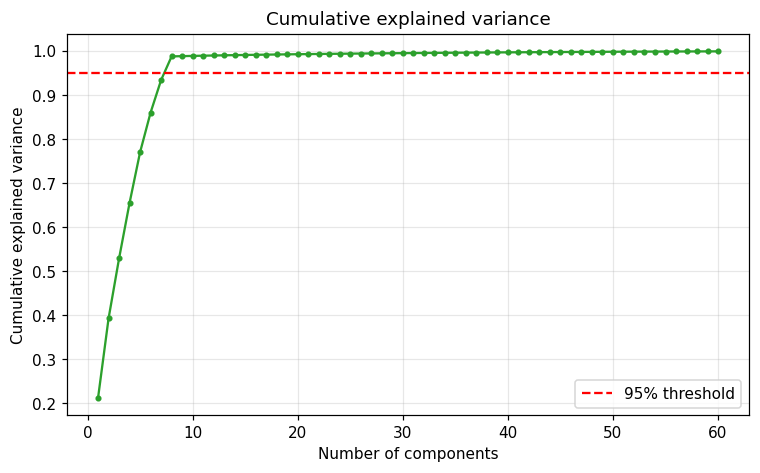

Components needed for >=95% variance: 8


In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, len(cum_evr) + 1), cum_evr, "o-", ms=3, color="tab:green")
ax.axhline(0.95, color="red", ls="--", label="95% threshold")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Cumulative explained variance")
ax.legend()
plt.show()

n95 = int(np.argmax(cum_evr >= 0.95) + 1)
print(f"Components needed for >=95% variance: {n95}")

In [9]:
# Numbers behind the plots
pd.DataFrame({
    "component": np.arange(1, 13),
    "explained_variance_ratio": evr[:12].round(4),
    "cumulative": cum_evr[:12].round(4),
})

,component,explained_variance_ratio,cumulative
0,1,0.2127,0.2127
1,2,0.1804,0.3931
2,3,0.1364,0.5295
3,4,0.1263,0.6558
4,5,0.1151,0.7709
5,6,0.0901,0.8610
6,7,0.0738,0.9348
7,8,0.0537,0.9886
8,9,0.0006,0.9892
9,10,0.0005,0.9897


**Visual elbow estimate (written from the scree plot, before any model comparison):**
The scree plot shows eight clearly separated components, with variance falling from roughly 21% (PC1) to about 5% (PC8). Then there is a sudden cliff: PC9 onwards sits at a tiny, flat ~0.05% each. **My visual elbow estimate is at 8 components.**

## 4.3 — Smallest component count that matches baseline accuracy

In [10]:
component_counts = [2, 4, 6, 8, 10, 12, 15, 20, 30, 40]
rows = []
for k in component_counts:
    pca_k = PCA(n_components=k, random_state=RANDOM_STATE).fit(X_train_s)   # fit on train only
    Z_train, Z_test = pca_k.transform(X_train_s), pca_k.transform(X_test_s)
    lr = LinearRegression().fit(Z_train, y_train)                            # fresh model each time
    rows.append({
        "n_components": k,
        "cum_explained_variance": pca_k.explained_variance_ratio_.sum(),
        "test_R2": r2_score(y_test, lr.predict(Z_test)),
    })

results = pd.DataFrame(rows)
results["diff_vs_baseline"] = results["test_R2"] - baseline_r2
results.round(4)

,n_components,cum_explained_variance,test_R2,diff_vs_baseline
0,2,0.3931,0.2409,-0.6174
1,4,0.6558,0.4989,-0.3595
2,6,0.8610,0.6946,-0.1638
3,8,0.9886,0.8716,0.0132
4,10,0.9897,0.8722,0.0139
5,12,0.9906,0.8718,0.0134
6,15,0.9918,0.8724,0.0140
7,20,0.9935,0.8725,0.0142
8,30,0.9960,0.8665,0.0081
9,40,0.9978,0.8634,0.0050


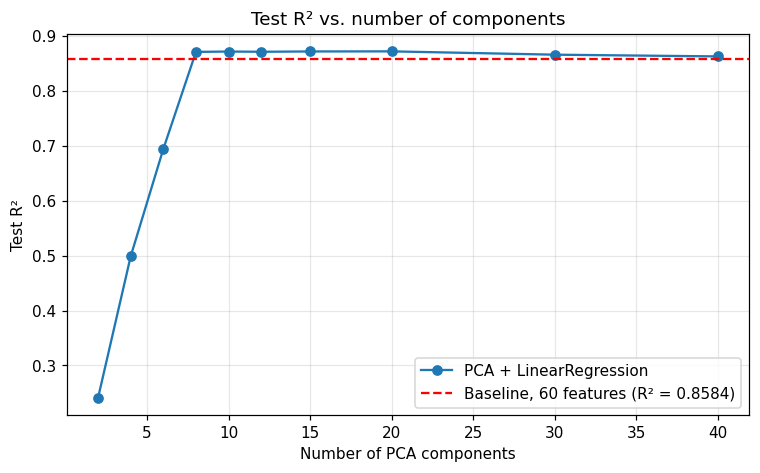

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(results["n_components"], results["test_R2"], "o-", label="PCA + LinearRegression")
ax.axhline(baseline_r2, color="red", ls="--", label=f"Baseline, 60 features (R² = {baseline_r2:.4f})")
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Test R²")
ax.set_title("Test R² vs. number of components")
ax.legend()
plt.show()

In [12]:
# Smallest k whose R² is within 0.01 of baseline (or exceeds it)
ok = results[results["test_R2"] >= baseline_r2 - 0.01]
best_k = int(ok["n_components"].min())
best_row = results[results["n_components"] == best_k].iloc[0]

print(f"Baseline R² (60 features):  {baseline_r2:.4f}")
print(f"Smallest k matching baseline: {best_k} components")
print(f"  Test R² at k={best_k}: {best_row['test_R2']:.4f}  (difference vs baseline: {best_row['diff_vs_baseline']:+.4f})")
print(f"  Variance retained: {best_row['cum_explained_variance']:.1%}")
print(f"Feature reduction: 60 -> {best_k}  ({1 - best_k/60:.0%} fewer)")
print(f"Visual elbow estimate: 8  |  Empirical answer: {best_k}  |  Agree: {best_k == 8}")

Baseline R² (60 features):  0.8584
Smallest k matching baseline: 8 components
  Test R² at k=8: 0.8716  (difference vs baseline: +0.0132)
  Variance retained: 98.9%
Feature reduction: 60 -> 8  (87% fewer)
Visual elbow estimate: 8  |  Empirical answer: 8  |  Agree: True


**Comparison with the elbow estimate:** The scree-plot elbow estimate (8) and the empirical answer from the R² search agree. The tested grid is coarse (2, 4, 6, 8, …), so the fact that k = 6 is clearly insufficient and k = 8 matches baseline accuracy brackets the answer tightly; the scree plot's sharp cliff after PC8 pins it to exactly 8.

## 4.4 — Explanation

The baseline using all 60 raw features reaches a test R² of about 0.858, and just 8 principal components reach about 0.872, which is slightly *better*, even though that is 87% fewer features. The scree plot shows why: eight components carry roughly 5–21% of the variance each, then variance collapses to ~0.05% per component, and those 8 together already hold about 98.9% of all the variance. This means the 60 original columns were not 60 independent pieces of information; they are largely redundant, correlated mixtures of about 8 underlying latent factors plus a little noise, so PCA recovers those factors and the rest is just repeated signal. Adding components beyond 8 gives no gain (R² stays ≈ 0.872 up to 20 components). The model can even become more accurate than the raw-feature baseline because the 60 correlated columns make Linear Regression estimate many unstable, collinear coefficients that fit noise in the training data; the ~52 discarded low-variance components are mostly noise, and dropping them acts as regularization and reduces overfitting. This is also visible at the high end of the chart, where R² slowly decays (0.8725 at 20 → 0.8634 at 40 components) as noise components are added back and the model drifts toward the baseline.